# 03 - EDA and Feature Engineering

**Objective:** Explore Wine data patterns and create new features.

**Steps:**
1. Statistical summary and class distribution
2. Visualizations (distributions, correlations, feature comparison by cultivar)
3. Feature scaling
4. Feature engineering (interaction and ratio features)
5. Save engineered data

In [59]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully")

Libraries imported successfully


In [60]:
# Load the clean data
PROCESSED_DIR = Path("../data/processed")

df = pd.read_csv(PROCESSED_DIR / "clean_data.csv")
print(f"Shape: {df.shape}")
print(f"\n--- Info ---")
df.info()
print(f"\n--- Head ---")
print(df.head())
print(f"\n--- Describe ---")
print(df.describe())


Shape: (178, 14)

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 178 non-null    int64  
 1   alcohol               178 non-null    float64
 2   malic_acid            178 non-null    float64
 3   ash                   178 non-null    float64
 4   alcalinity_of_ash     178 non-null    float64
 5   magnesium             178 non-null    int64  
 6   total_phenols         178 non-null    float64
 7   flavanoids            178 non-null    float64
 8   nonflavanoid_phenols  178 non-null    float64
 9   proanthocyanins       178 non-null    float64
 10  color_intensity       178 non-null    float64
 11  hue                   178 non-null    float64
 12  od280_od315           178 non-null    float64
 13  proline               178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6

### Statistical Summary & Distribution

Before building any models, it is important to understand the range and spread of your data.
The target variable — `class` — has three categories (a multi-class classification problem).
The three cultivars have 59, 71, and 48 samples, so the dataset is slightly imbalanced.

Wine has 13 continuous features measuring chemical properties of the wines.

In [61]:
# TODO: Examine the target variable distribution and feature summary
# Use df.describe() to see min, max, mean, and quartiles for all 13 features.

In [62]:
# Summary statistics for all 13 features
print("=== Descriptive Statistics ===")
print(df.describe().round(2))

print("\n=== Class Distribution ===")
print(df["class"].value_counts().sort_index())
print(f"\nClass proportions:")
print(df["class"].value_counts(normalize=True).sort_index().round(3))


=== Descriptive Statistics ===
        class  alcohol  malic_acid     ash  alcalinity_of_ash  magnesium  \
count  178.00   178.00      178.00  178.00             178.00     178.00   
mean     0.94    13.00        2.34    2.37              19.49      99.74   
std      0.78     0.81        1.12    0.27               3.34      14.28   
min      0.00    11.03        0.74    1.36              10.60      70.00   
25%      0.00    12.36        1.60    2.21              17.20      88.00   
50%      1.00    13.05        1.87    2.36              19.50      98.00   
75%      2.00    13.68        3.08    2.56              21.50     107.00   
max      2.00    14.83        5.80    3.23              30.00     162.00   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count         178.00      178.00                178.00           178.00   
mean            2.30        2.03                  0.36             1.59   
std             0.63        1.00                  0.12     

#### A little primer on groupby 

- `groupby` is a powerful pandas method that allows you to split your data into groups based on some criteria, apply a function to each group, and then combine the results. For example, to see how average alcohol differs between cultivars, you can do:

```python
alcohol_by_cultivar = df.groupby("class")["alcohol"].mean()
```

- `aggregate` is a method that allows you to apply multiple functions to your grouped data. For example, to get both the mean and standard deviation of color intensity by cultivar, you can do:

```python
stats_by_species = df.groupby("class")["color_intensity"].aggregate(["mean", "std"])
```

Aggregate functions can be any function that takes a Series and returns a single value, such as `mean`, `std`, `min`, `max`, etc.
Aggregate can be deployed on multiple columns at once, and you can specify different functions for each column if needed.

In [63]:
# === Executed Example: GroupBy and Aggregate ===
# Small inline dataset showing how groupby splits data by class
# and compares flower measurements between species.

import pandas as pd

data = pd.DataFrame({
    "class": [0, 0, 0, 1, 1, 1],
    "color_intensity": [5.1, 4.9, 5.0, 6.0, 6.2, 5.9],
    "alcohol": [1.4, 1.5, 1.3, 4.5, 4.7, 4.4],
})

mean_by_class = data.groupby("class")["alcohol"].mean()
print("Average alcohol by class:\n", mean_by_class)

stats_by_class = data.groupby("class")["color_intensity"].agg(["mean", "std", "min", "max"])
print("\nColor intensity statistics by class:\n", stats_by_class)

Average alcohol by class:
 class
0    1.400000
1    4.533333
Name: alcohol, dtype: float64

Color intensity statistics by class:
            mean       std  min  max
class                              
0      5.000000  0.100000  4.9  5.1
1      6.033333  0.152753  5.9  6.2


### Missing Value Imputation

Real-world datasets often have missing values.
Our clean data does not, but this section shows the tools to handle them.

Common strategies:
- **Drop rows**: `df.dropna()` — fast, loses samples
- **Mean/Median imputation**: `SimpleImputer(strategy='median')` — preserves sample count
- **KNN imputation**: `KNNImputer()` — estimates from neighbors, more robust
- **Forward fill**: `df.ffill()` — for sequential data

In [64]:
# === Executed Example: Missing Value Imputation ===
# Using SimpleImputer to fill missing values with the mean.

from sklearn.impute import SimpleImputer

data = pd.DataFrame({
    "color_intensity": [5.1, np.nan, 5.0, 6.0, np.nan],
    "alcohol": [1.4, 1.5, np.nan, 4.5, 4.7],
})

print("Before imputation:")
print(data)

imputer = SimpleImputer(strategy='mean')
imputed = imputer.fit_transform(data)
imputed_df = pd.DataFrame(imputed, columns=data.columns)
print("\nAfter imputation (mean strategy):")
print(imputed_df)
print(f"\nImputed color_intensity: {imputer.statistics_[0]:.3f}")
print(f"Imputed alcohol: {imputer.statistics_[1]:.3f}")

Before imputation:
   color_intensity  alcohol
0              5.1      1.4
1              NaN      1.5
2              5.0      NaN
3              6.0      4.5
4              NaN      4.7

After imputation (mean strategy):
   color_intensity  alcohol
0         5.100000    1.400
1         5.366667    1.500
2         5.000000    3.025
3         6.000000    4.500
4         5.366667    4.700

Imputed color_intensity: 5.367
Imputed alcohol: 3.025


In [65]:
# TODO: Compare feature distributions by cultivar
# Which measurements best separate the three species?
# Use boxplots to compare all 4 features.
# Cultivar_1 should separate clearly on certain chemical features.
#
# features_to_plot = ["color_intensity", "hue", "alcohol", "proline"]
# fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# for ax, feature in zip(axes.ravel(), features_to_plot):
#     sns.boxplot(x="class", y=feature, data=df, ax=ax)
#     ax.set_title(f"{feature} by class")
# plt.tight_layout()
# plt.show()

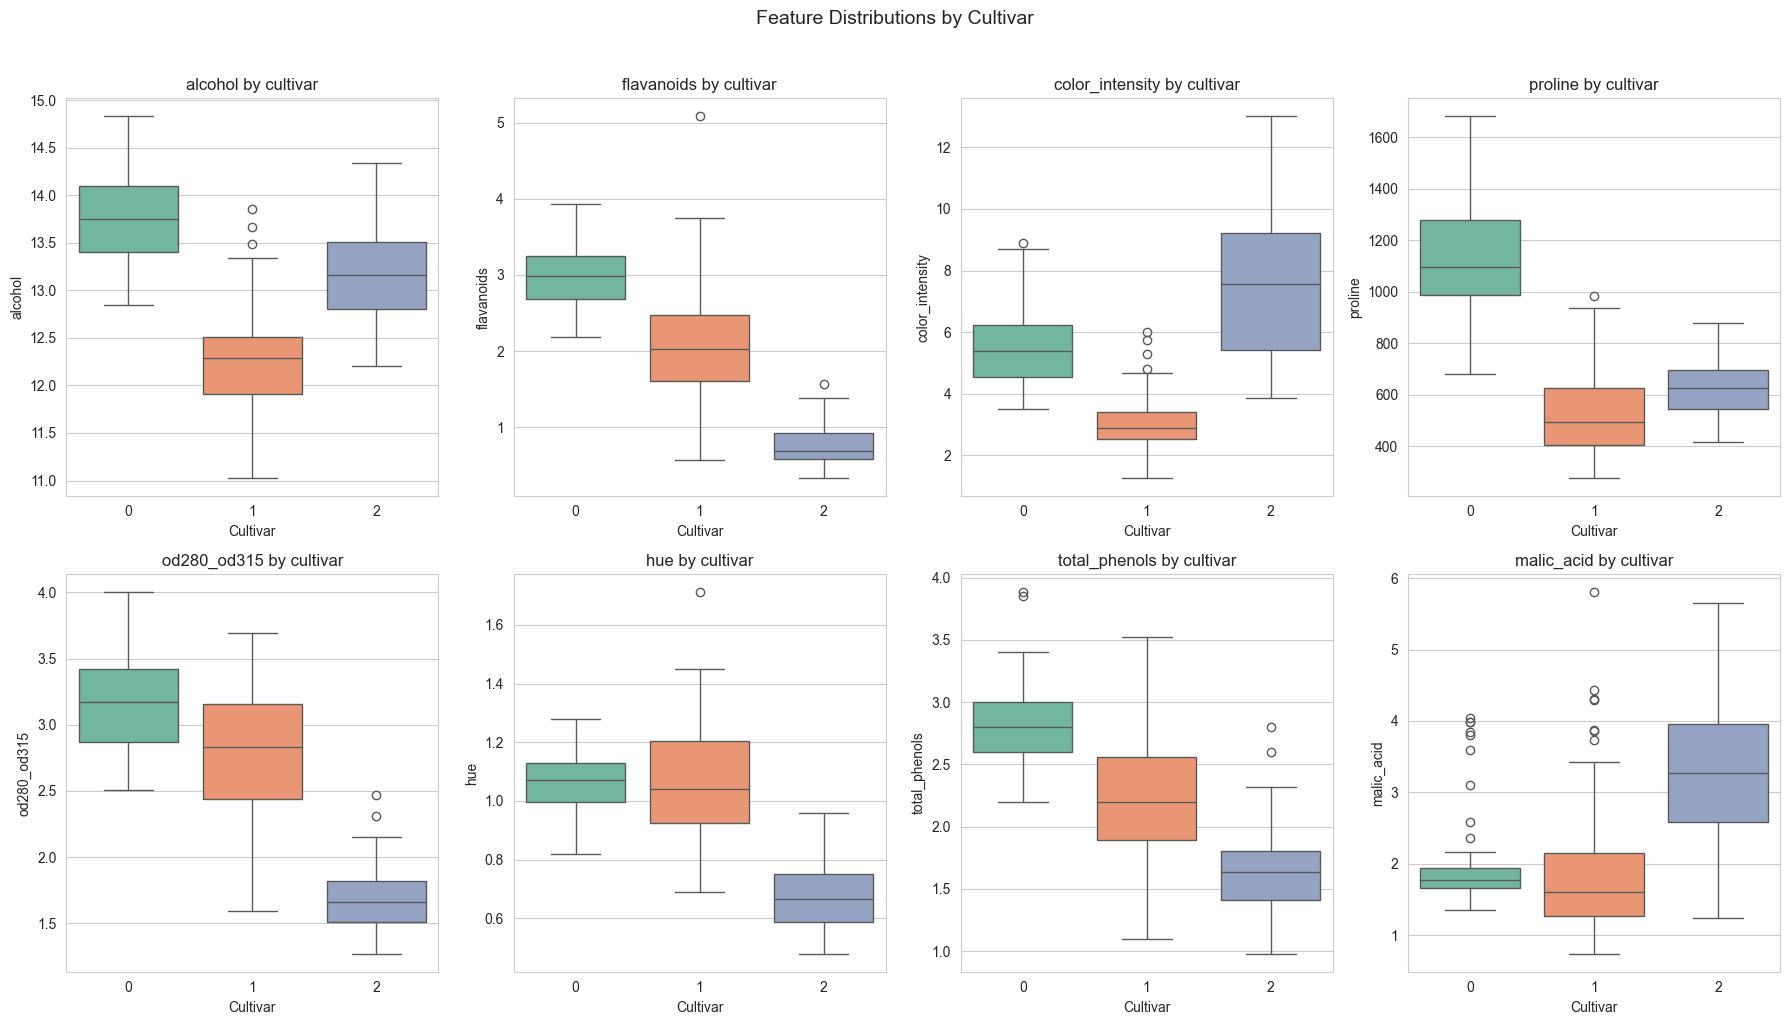

In [88]:
# Boxplots comparing feature distributions by cultivar
features_to_plot = ["alcohol", "flavanoids", "color_intensity", "proline",
                    "od280_od315", "hue", "total_phenols", "malic_acid"]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
for ax, feature in zip(axes.ravel(), features_to_plot):
    sns.boxplot(x="class", y=feature, hue="class", data=df, ax=ax, palette="Set2", legend=False)
    ax.set_title(f"{feature} by cultivar")
    ax.set_xlabel("Cultivar")

plt.suptitle("Feature Distributions by Cultivar", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### Visualizations

Visual exploration helps you spot patterns and relationships that summary statistics miss.
Focus on:
- How each feature is distributed (histograms)
- Which features correlate with each other and with the target (heatmap)
- Which features separate the three species (boxplots)

In [67]:
# TODO: Plot histograms for all numerical features
# Wine has 13 features; select the most informative ones to plot.
# Use df[features].hist() with bins=15 and a large figure size.

# features_to_plot = ["color_intensity", "hue", "alcohol", "proline"]
# df[features_to_plot].hist(bins=15, figsize=(12, 8))
# plt.tight_layout()
# plt.show()

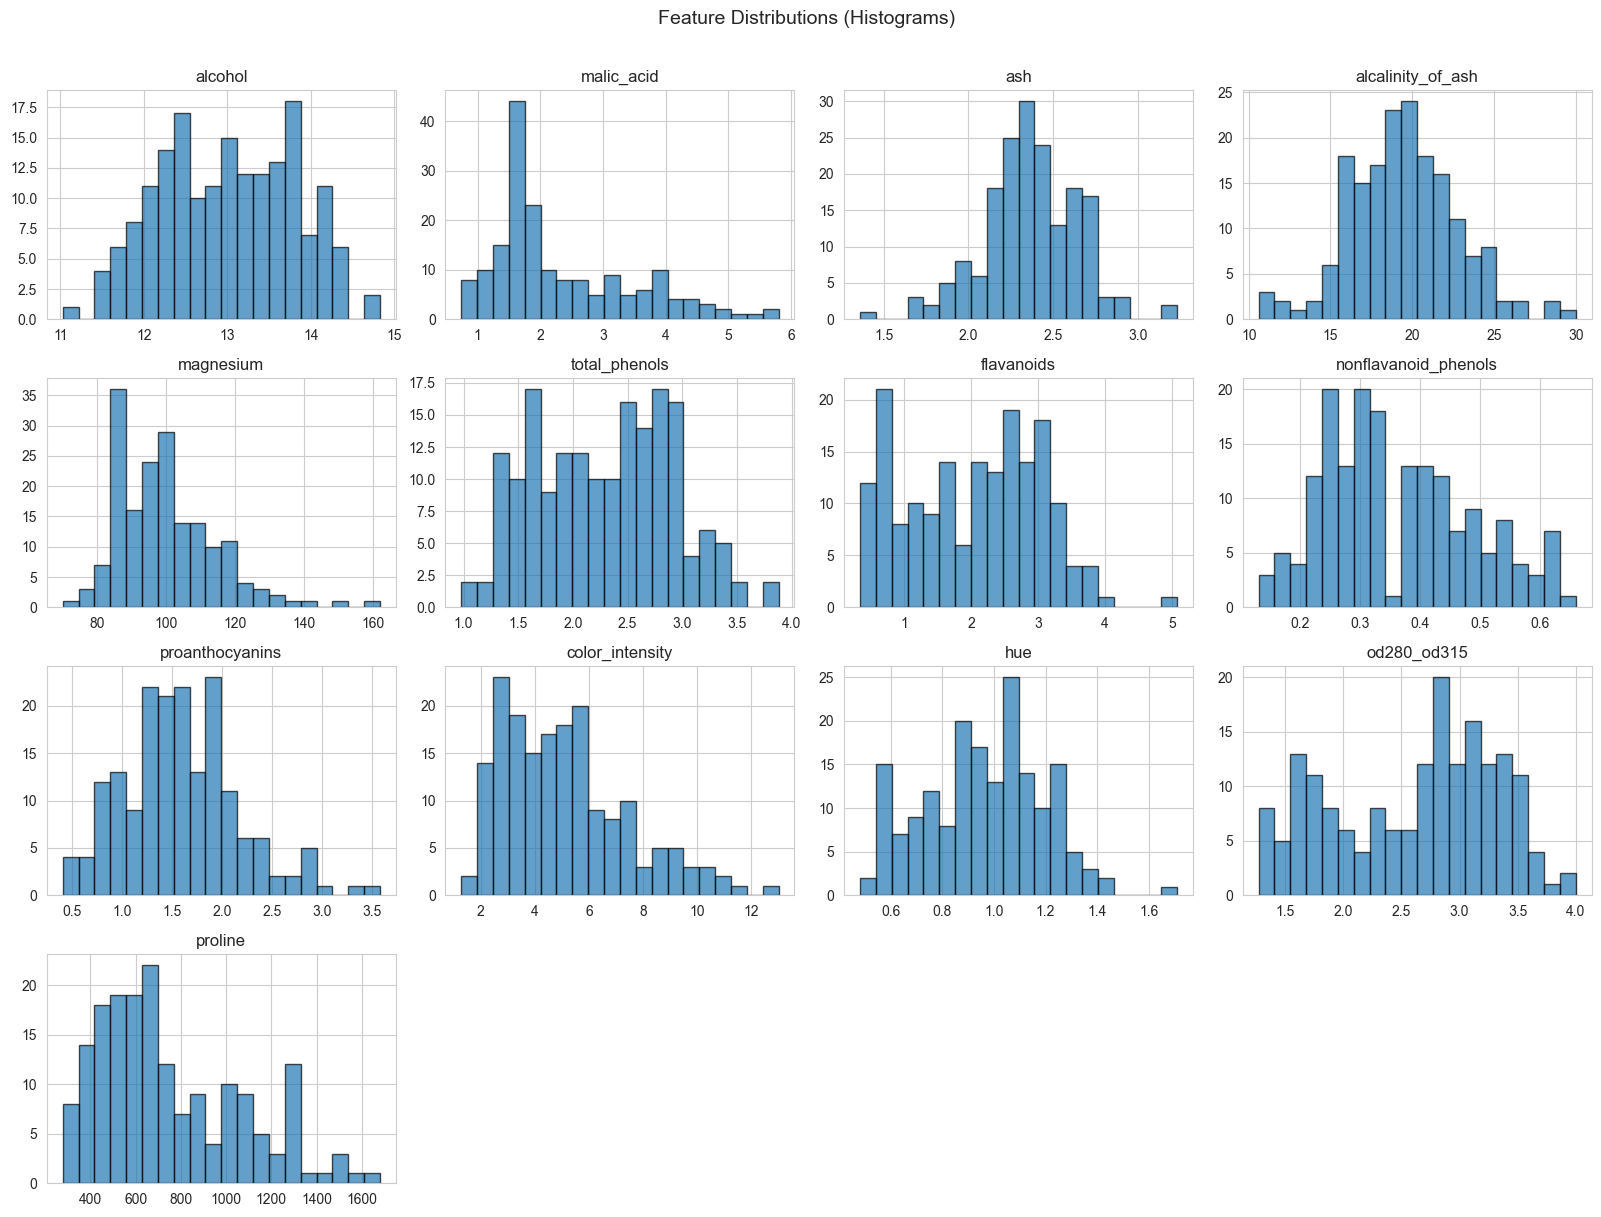

In [68]:
# Histograms for all 13 numeric features
numeric_features = df.columns.drop("class")
df[numeric_features].hist(bins=20, figsize=(16, 12), edgecolor="black", alpha=0.7)
plt.suptitle("Feature Distributions (Histograms)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


In [69]:
# TODO: Create a correlation heatmap
# Use df.corr() to compute pairwise correlations between numeric columns.
# With 13 features + the target, the full heatmap is easy to read.
# Then visualize with sns.heatmap().
#
# TODO: Identify the features most correlated with species
# Sort the correlation values for the class column to see which features
# best distinguish the three species.

# plt.figure(figsize=(8, 6))
# sns.heatmap(df.corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
# plt.title("Feature Correlation Heatmap")
# plt.show()
#
# target_corr = df.corr()["class"].sort_values(ascending=False)
# print("Correlations with class:")
# print(target_corr)

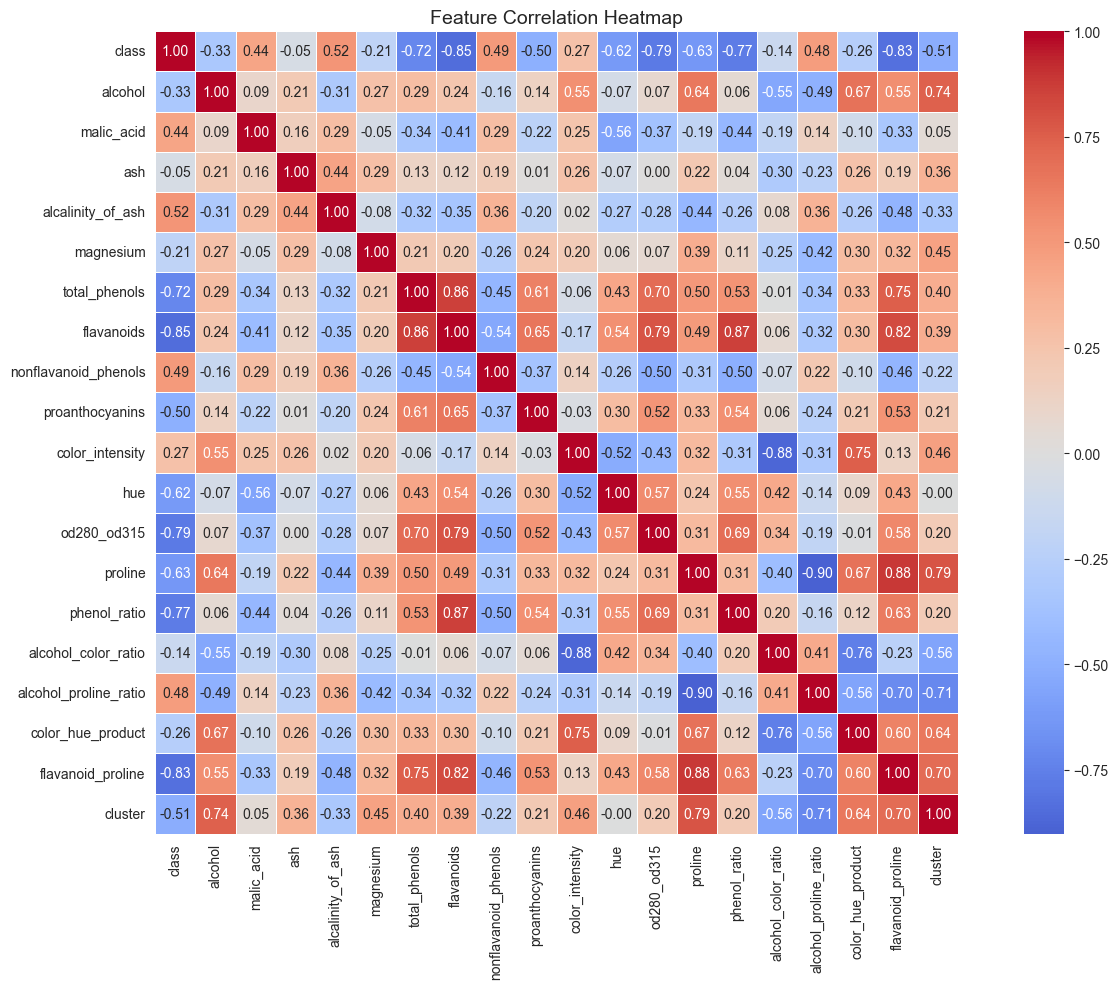


=== Correlations with target (class) ===
flavanoids              -0.847
flavanoid_proline       -0.831
od280_od315             -0.788
phenol_ratio            -0.768
total_phenols           -0.719
proline                 -0.634
hue                     -0.617
alcalinity_of_ash        0.518
cluster                 -0.509
proanthocyanins         -0.499
nonflavanoid_phenols     0.489
alcohol_proline_ratio    0.480
malic_acid               0.438
alcohol                 -0.328
color_intensity          0.266
color_hue_product       -0.257
magnesium               -0.209
alcohol_color_ratio     -0.136
ash                     -0.050
Name: class, dtype: float64

--- Top discriminative features ---
  Strongest positive: alcalinity_of_ash (0.518)
  Strongest negative: flavanoids (-0.847)


In [89]:
# Correlation heatmap
plt.figure(figsize=(14, 10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f",
            square=True, linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

# Features most correlated with target class
print("\n=== Correlations with target (class) ===")
target_corr = corr_matrix["class"].drop("class").sort_values(key=abs, ascending=False)
print(target_corr.round(3))

print("\n--- Top discriminative features ---")
print(f"  Strongest positive: {target_corr.idxmax()} ({target_corr.max():.3f})")
print(f"  Strongest negative: {target_corr.idxmin()} ({target_corr.min():.3f})")

### Feature Scaling

Many machine learning algorithms (SVM, logistic regression, neural networks) are sensitive to
the scale of input features. StandardScaler transforms each feature to have mean 0 and
standard deviation 1, which puts all features on equal footing.

Tree-based models (Random Forest, XGBoost) do not require scaling since they split on
thresholds independently of feature magnitude.

In [71]:
# === Executed Example: Feature Scaling ===
# Small inline dataset showing how StandardScaler transforms features
# to have mean ~0 and std ~1.

from sklearn.preprocessing import StandardScaler
import pandas as pd

data = pd.DataFrame({
    "color_intensity": [5.1, 4.9, 5.0, 6.0, 6.2],
    "alcohol": [1.4, 1.5, 1.3, 4.5, 4.7],
    "class": [0, 0, 0, 1, 1],
})

scaler = StandardScaler()
scaled_features = scaler.fit_transform(data[["color_intensity", "alcohol"]])
scaled_df = pd.DataFrame(scaled_features, columns=["color_intensity_scaled", "alcohol_scaled"])
scaled_df["class"] = data["class"]
print(scaled_df)
print(f"Means after scaling: {scaled_df[['color_intensity_scaled', 'alcohol_scaled']].mean().values}")
print(f"Stds after scaling: {scaled_df[['color_intensity_scaled', 'alcohol_scaled']].std().values}")

   color_intensity_scaled  alcohol_scaled  class
0               -0.622414       -0.815171      0
1               -0.988540       -0.751486      0
2               -0.805477       -0.878856      0
3                1.025153        1.159071      1
4                1.391279        1.286442      1
Means after scaling: [9.76996262e-16 1.33226763e-16]
Stds after scaling: [1.11803399 1.11803399]


In [72]:
from sklearn.preprocessing import StandardScaler

# TODO: Scale the 4 numeric features
# Wine has only continuous features with different units and scales.
# StandardScaler normalises them so SVM / logistic regression aren't biased
# by the absolute magnitude of each measurement.
#
# Create a StandardScaler, call fit_transform() to compute the mean and std
# and return the scaled array in one step.
#
# After scaling, verify that each feature has mean ~0 and std ~1.

# numeric_features = ["color_intensity", "hue", "alcohol", "proline"]
# scaler = StandardScaler()
# df_scaled = scaler.fit_transform(df[numeric_features])
#
# Rename the scaled columns with a "_scaled" suffix
# df_scaled = pd.DataFrame(df_scaled, columns=[f"{col}_scaled" for col in numeric_features])
# print(f"Means after scaling: {df_scaled.mean().values}")
# print(f"Stds after scaling: {df_scaled.std().values}")
# print(f"All means near zero: {np.allclose(df_scaled.mean(), 0, atol=1e-10)}")

In [73]:
from sklearn.preprocessing import StandardScaler

# Scale all 13 numeric features
numeric_features = df.columns.drop("class")
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df[numeric_features]),
    columns=[f"{col}_scaled" for col in numeric_features]
)

# Verify scaling: mean ~0, std ~1
print("=== After StandardScaler ===")
print(f"Means (should be ~0): {df_scaled.mean().values.round(10)}")
print(f"Stds  (should be ~1): {df_scaled.std().values.round(4)}")
print(f"\nAll means near zero: {np.allclose(df_scaled.mean(), 0, atol=1e-10)}")
print(f"All stds near one:   {np.allclose(df_scaled.std(), 1, atol=0.01)}")

# Show before vs after for a few features
print("\n--- Before scaling (first 5 rows) ---")
print(df[["alcohol", "proline", "hue"]].head())
print("\n--- After scaling (first 5 rows) ---")
print(df_scaled[["alcohol_scaled", "proline_scaled", "hue_scaled"]].head())


=== After StandardScaler ===
Means (should be ~0): [-0. -0. -0. -0. -0.  0. -0.  0. -0.  0.  0.  0. -0.]
Stds  (should be ~1): [1.0028 1.0028 1.0028 1.0028 1.0028 1.0028 1.0028 1.0028 1.0028 1.0028
 1.0028 1.0028 1.0028]

All means near zero: True
All stds near one:   True

--- Before scaling (first 5 rows) ---
   alcohol  proline   hue
0    14.23     1065  1.04
1    13.20     1050  1.05
2    13.16     1185  1.03
3    14.37     1480  0.86
4    13.24      735  1.04

--- After scaling (first 5 rows) ---
   alcohol_scaled  proline_scaled  hue_scaled
0        1.518613        1.013009    0.362177
1        0.246290        0.965242    0.406051
2        0.196879        1.395148    0.318304
3        1.691550        2.334574   -0.427544
4        0.295700       -0.037874    0.362177


### Feature Engineering

New features derived from existing columns can capture interactions and non-linear relationships.
Good candidates for Wine:
- **Phenol ratio**: `alcohol × proline` — proportion of flavanoid phenols
- **Color-hue product**: `color_intensity × hue` — combined color metric
- **Alcohol-color ratio**: `alcohol / color_intensity` — relative flower proportion

Be careful with division by zero — add a small epsilon or +1 to the denominator.

#### Note

In pandas, you can create interaction features like this:

```python
df["feature1_feature2"] = df["feature1"] * df["feature2"]
```

In [74]:
# === Executed Example: Interaction Features ===
# Multiplication and ratio on a small inline dataset.

import pandas as pd

data = pd.DataFrame({
    "color_intensity": [5.1, 4.9, 6.0, 6.2, 5.9],
    "hue": [3.5, 3.0, 3.3, 2.9, 3.0],
    "alcohol": [1.4, 1.5, 4.5, 4.7, 4.4],
    "proline": [0.2, 0.2, 1.5, 1.6, 1.4],
})

data["phenol_ratio"] = data["alcohol"] * data["proline"]
print("Phenol ratio:\n", data[["alcohol", "proline", "phenol_ratio"]])

data["alcohol_color_ratio"] = data["alcohol"] / data["color_intensity"]
print("\nAlcohol / Color ratio:\n", data[["alcohol", "color_intensity", "alcohol_color_ratio"]])

Phenol ratio:
    alcohol  proline  phenol_ratio
0      1.4      0.2          0.28
1      1.5      0.2          0.30
2      4.5      1.5          6.75
3      4.7      1.6          7.52
4      4.4      1.4          6.16

Alcohol / Color ratio:
    alcohol  color_intensity  alcohol_color_ratio
0      1.4              5.1             0.274510
1      1.5              4.9             0.306122
2      4.5              6.0             0.750000
3      4.7              6.2             0.758065
4      4.4              5.9             0.745763


In [75]:
# === Commented Template: Interaction Features ===
# Uncomment and adapt to your own dataset.

# import pandas as pd
# data = pd.DataFrame({
#     "feature_a": [val1, val2, val3],
#     "feature_b": [val1, val2, val3],
# })
# data["a_times_b"] = data["feature_a"] * data["feature_b"]
# EPS = 1e-6
# data["a_over_b"] = data["feature_a"] / (data["feature_b"] + EPS)

In [76]:
# TODO: Create new features based on flower morphology
# The Wine dataset has chemical measurements. Ratio and product
# features can make species separation more pronounced.
#
# Examples:
#   df["phenol_ratio"] = df["alcohol"] * df["proline"]
#   df["color_hue_product"] = df["color_intensity"] * df["hue"]
#   df["alcohol_color_ratio"] = df["alcohol"] / df["color_intensity"]
#
# TODO: Verify the new features
# Check that they have finite values and reasonable ranges with .describe().

In [77]:
# Feature Engineering: create interaction and ratio features
EPS = 1e-6  # avoid division by zero

# Ratio features
df["phenol_ratio"] = df["flavanoids"] / (df["total_phenols"] + EPS)
df["alcohol_color_ratio"] = df["alcohol"] / (df["color_intensity"] + EPS)
df["alcohol_proline_ratio"] = df["alcohol"] / (df["proline"] + EPS)

# Product features
df["color_hue_product"] = df["color_intensity"] * df["hue"]
df["flavanoid_proline"] = df["flavanoids"] * df["proline"]

# Verify new features
print("=== Engineered Features ===")
new_features = ["phenol_ratio", "alcohol_color_ratio", "alcohol_proline_ratio",
                "color_hue_product", "flavanoid_proline"]
print(df[new_features].describe().round(3))

# Check if any feature has infinite or NaN values
print(f"\nAny NaN: {df[new_features].isna().any().any()}")
print(f"Any Inf: {np.isinf(df[new_features]).any().any()}")

# Compare engineered features by cultivar
print("\n=== Engineered Features by Cultivar ===")
print(df.groupby("class")[new_features].mean().round(3))


=== Engineered Features ===
       phenol_ratio  alcohol_color_ratio  alcohol_proline_ratio  \
count       178.000              178.000                178.000   
mean          0.844                3.107                  0.020   
std           0.283                1.344                  0.008   
min           0.259                1.103                  0.008   
25%           0.622                2.202                  0.014   
50%           0.938                2.817                  0.019   
75%           1.057                3.872                  0.025   
max           1.597                9.375                  0.043   

       color_hue_product  flavanoid_proline  
count            178.000            178.000  
mean               4.568           1670.222  
std                1.732           1374.208  
min                1.190            141.100  
25%                3.251            631.125  
50%                4.508           1004.350  
75%                5.615           2690.888  


In [78]:
# TODO: Save the engineered data for the next notebook
# Include both the original and new features.

PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# df.to_csv(PROCESSED_DIR / "engineered_data.csv", index=False)
# print("Engineered data saved to data/processed/engineered_data.csv")

In [79]:
# Save engineered data (original + new features)
PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

df.to_csv(PROCESSED_DIR / "engineered_data.csv", index=False)
print(f"Engineered data saved: {PROCESSED_DIR / 'engineered_data.csv'}")
print(f"Shape: {df.shape} ({len(new_features)} new features added)")
print(f"Columns: {df.columns.tolist()}")


Engineered data saved: ..\data\processed\engineered_data.csv
Shape: (178, 19) (5 new features added)
Columns: ['class', 'alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280_od315', 'proline', 'phenol_ratio', 'alcohol_color_ratio', 'alcohol_proline_ratio', 'color_hue_product', 'flavanoid_proline']


### Unsupervised Clustering (KMeans)

Clustering groups observations without using the target labels.
We use **KMeans** which partitions data into $k$ clusters by minimizing
within-cluster variance.

**Questions:**
- Do the clusters found by KMeans align with the actual class classes?
- How many natural groups exist in the data?


In [80]:
# TODO: Apply KMeans clustering and compare with target labels
# Clustering groups data without using labels.
# Use the elbow method to find optimal k, then compare clusters vs target.

# from sklearn.cluster import KMeans
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import adjusted_rand_score
# from sklearn.decomposition import PCA

# Step 1: Scale features
# X_clust = df.drop("class", axis=1).select_dtypes(include=[np.number])
# X_clust_scaled = StandardScaler().fit_transform(X_clust)
#
# Step 2: Elbow method for k=2..10
# inertias = []
# for k in range(2, min(11, X_clust_scaled.shape[1] + 1)):
#     kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
#     kmeans.fit(X_clust_scaled)
#     inertias.append(kmeans.inertia_)
#
# Step 3: Plot elbow curve
# plt.plot(range(2, min(11, X_clust_scaled.shape[1] + 1)), inertias, 'bo-')
# plt.xlabel('k'); plt.ylabel('Inertia'); plt.title('Elbow Method')
# plt.show()
#
# Step 4: Fit KMeans and compare with target
# df["Cluster"] = KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(X_clust_scaled)
# ari = adjusted_rand_score(df["class"], df["Cluster"])
# print(f"Adjusted Rand Index: {ari:.4f}")
# print(pd.crosstab(df["Cluster"], df["class"]))
#
# Step 5: Visualize via PCA
# pca_vis = PCA(n_components=2, random_state=42)
# X_pca_vis = pca_vis.fit_transform(X_clust_scaled)
# plt.scatter(X_pca_vis[:, 0], X_pca_vis[:, 1], c=df['Cluster'], cmap='viridis', edgecolors='k', alpha=0.7)
# plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('KMeans Clusters')
# plt.show()


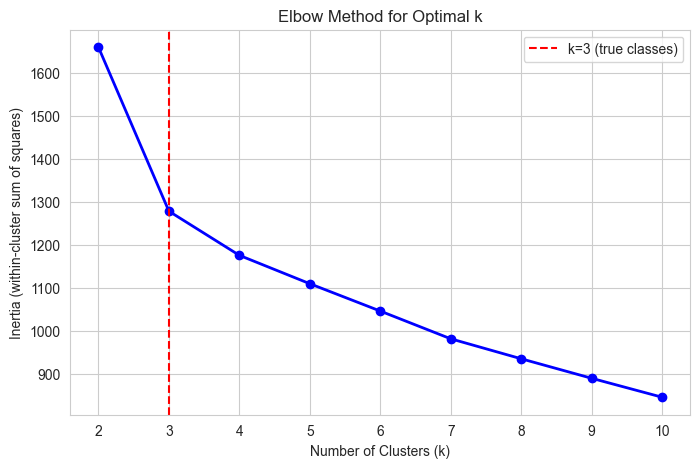

Adjusted Rand Index (k=3): 0.8975
  (1.0 = perfect match, 0.0 = random)

Cross-tabulation (Cluster vs True Class):
class     0   1   2  All
cluster                 
0         0  65   0   65
1         0   3  48   51
2        59   3   0   62
All      59  71  48  178


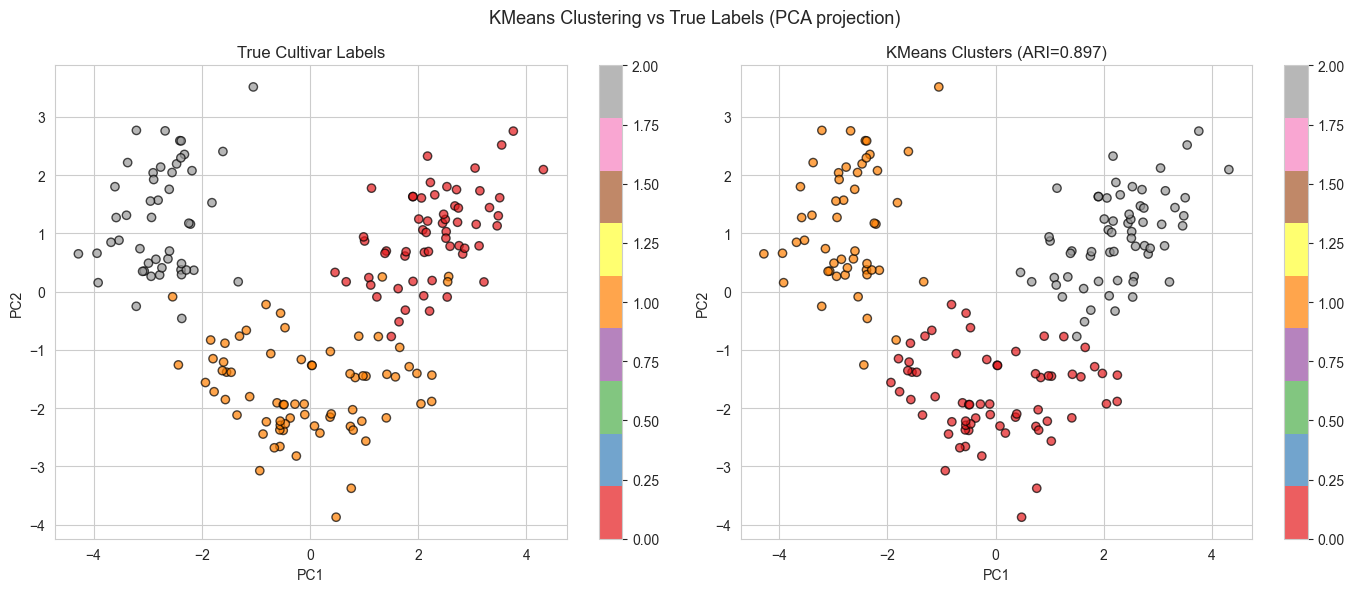

In [81]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score
from sklearn.decomposition import PCA

# Prepare data for clustering (exclude target and engineered features)
original_features = ["alcohol", "malic_acid", "ash", "alcalinity_of_ash", "magnesium",
                     "total_phenols", "flavanoids", "nonflavanoid_phenols",
                     "proanthocyanins", "color_intensity", "hue", "od280_od315", "proline"]
X_clust = df[original_features].copy()
X_clust_scaled = StandardScaler().fit_transform(X_clust)

# Elbow method
inertias = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_clust_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (within-cluster sum of squares)')
plt.title('Elbow Method for Optimal k')
plt.axvline(x=3, color='r', linestyle='--', label='k=3 (true classes)')
plt.legend()
plt.show()

# Fit KMeans with k=3 (matching true number of cultivars)
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans_3.fit_predict(X_clust_scaled)

# Compare clusters to true labels
ari = adjusted_rand_score(df["class"], df["cluster"])
print(f"Adjusted Rand Index (k=3): {ari:.4f}")
print(f"  (1.0 = perfect match, 0.0 = random)")
print(f"\nCross-tabulation (Cluster vs True Class):")
print(pd.crosstab(df["cluster"], df["class"], margins=True))

# Visualize clusters in PCA space
pca_vis = PCA(n_components=2, random_state=42)
X_pca_vis = pca_vis.fit_transform(X_clust_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
scatter1 = ax1.scatter(X_pca_vis[:, 0], X_pca_vis[:, 1], c=df["class"],
                       cmap="Set1", edgecolors="k", alpha=0.7)
ax1.set_title("True Cultivar Labels")
ax1.set_xlabel("PC1"); ax1.set_ylabel("PC2")
plt.colorbar(scatter1, ax=ax1)

scatter2 = ax2.scatter(X_pca_vis[:, 0], X_pca_vis[:, 1], c=df["cluster"],
                       cmap="Set1", edgecolors="k", alpha=0.7)
ax2.set_title(f"KMeans Clusters (ARI={ari:.3f})")
ax2.set_xlabel("PC1"); ax2.set_ylabel("PC2")
plt.colorbar(scatter2, ax=ax2)

plt.suptitle("KMeans Clustering vs True Labels (PCA projection)", fontsize=13)
plt.tight_layout()
plt.show()


### Principal Component Analysis (PCA)

PCA finds orthogonal axes (principal components) that capture the maximum variance
in the data. It is useful for:
- **Dimensionality reduction**: compressing many features into fewer components
- **Visualization**: projecting high-dimensional data to 2D or 3D
- **Noise reduction**: discarding low-variance components

PCA is **unsupervised** — it does not use the target labels.


In [82]:
# TODO: Apply PCA for dimensionality reduction and visualization
# PCA finds the axes of maximum variance in the data.
# It can reduce high-dimensional data to 2D for visualization.

# from sklearn.decomposition import PCA
# from sklearn.preprocessing import StandardScaler

# X = df.drop("class", axis=1).select_dtypes(include=[np.number])
# if "Cluster" in X.columns:
#     X = X.drop("Cluster", axis=1)
# X_scaled = StandardScaler().fit_transform(X)
#
# Step 1: Fit PCA with min(n_features, 10) components
# n_comps = min(X.shape[1], 10)
# pca = PCA(n_components=n_comps, random_state=42)
# X_pca = pca.fit_transform(X_scaled)
#
# Step 2: Scree plot
# plt.bar(range(1, n_comps + 1), pca.explained_variance_ratio_)
# plt.xlabel('PC'); plt.ylabel('Explained Variance Ratio')
# plt.title('Scree Plot'); plt.show()
#
# Step 3: Cumulative explained variance
# cumulative = np.cumsum(pca.explained_variance_ratio_)
# plt.plot(range(1, n_comps + 1), cumulative, 'bo-')
# plt.axhline(y=0.95, color='r', linestyle='--', label='95%')
# plt.legend(); plt.show()
#
# Step 4: 2D PCA scatter colored by target
# plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["class"], cmap="coolwarm", edgecolors="k", alpha=0.7)
# plt.xlabel('PC1'); plt.ylabel('PC2')
# plt.title('PCA Projection'); plt.colorbar()
# plt.show()
#
# Step 5: Inspect feature loadings
# loadings = pd.DataFrame(
#     pca.components_.T[:, :3],
#     index=X.columns,
#     columns=['PC1', 'PC2', 'PC3'],
# )
# print(loadings['PC1'].abs().sort_values(ascending=False).head(5))


Components needed for 95% variance: 10
Cumulative variance: [0.362 0.554 0.665 0.736 0.802 0.851 0.893 0.92  0.942 0.962]


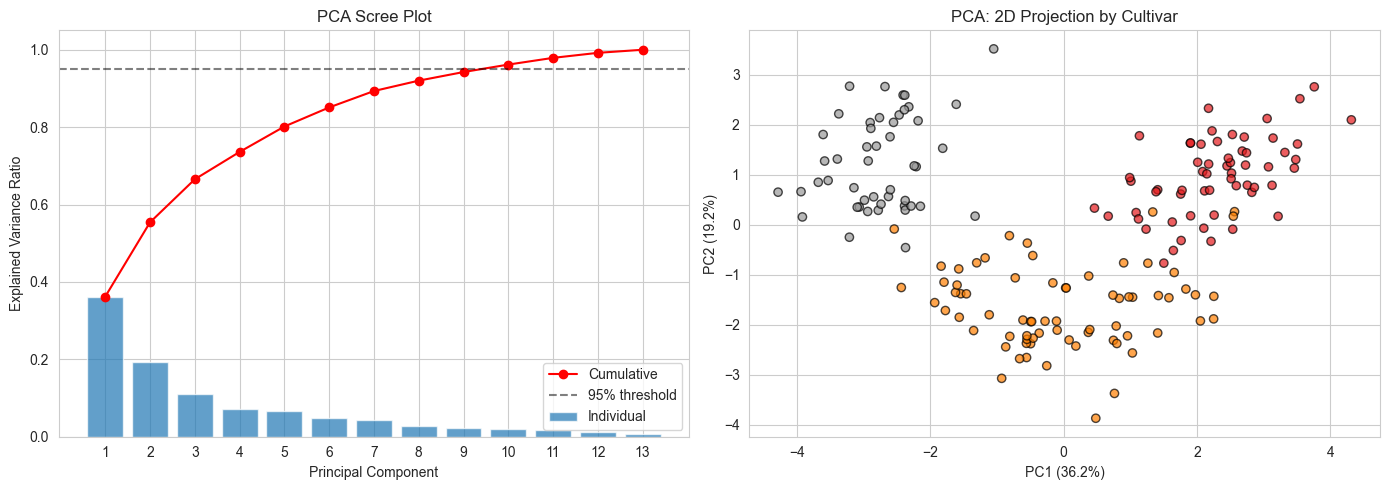


=== PCA Loadings (first 3 components) ===
                        PC1    PC2    PC3
alcohol               0.144  0.484 -0.207
malic_acid           -0.245  0.225  0.089
ash                  -0.002  0.316  0.626
alcalinity_of_ash    -0.239 -0.011  0.612
magnesium             0.142  0.300  0.131
total_phenols         0.395  0.065  0.146
flavanoids            0.423 -0.003  0.151
nonflavanoid_phenols -0.299  0.029  0.170
proanthocyanins       0.313  0.039  0.149
color_intensity      -0.089  0.530 -0.137
hue                   0.297 -0.279  0.085
od280_od315           0.376 -0.164  0.166
proline               0.287  0.365 -0.127

Top features for PC1: ['flavanoids', 'total_phenols', 'od280_od315']
Top features for PC2: ['color_intensity', 'alcohol', 'proline']


In [83]:
from sklearn.decomposition import PCA

# PCA on all 13 original features (scaled)
pca_full = PCA(random_state=42)
X_pca_full = pca_full.fit_transform(X_clust_scaled)

# Scree plot: explained variance ratio
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(range(1, 14), pca_full.explained_variance_ratio_, alpha=0.7, label="Individual")
ax1.plot(range(1, 14), np.cumsum(pca_full.explained_variance_ratio_), 'ro-', label="Cumulative")
ax1.axhline(y=0.95, color='k', linestyle='--', alpha=0.5, label="95% threshold")
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Explained Variance Ratio")
ax1.set_title("PCA Scree Plot")
ax1.legend()
ax1.set_xticks(range(1, 14))

# Number of components for 95% variance
n_95 = np.argmax(np.cumsum(pca_full.explained_variance_ratio_) >= 0.95) + 1
print(f"Components needed for 95% variance: {n_95}")
print(f"Cumulative variance: {np.cumsum(pca_full.explained_variance_ratio_)[:n_95].round(3)}")

# 2D PCA scatter colored by cultivar
ax2.scatter(X_pca_full[:, 0], X_pca_full[:, 1], c=df["class"], cmap="Set1",
            edgecolors="k", alpha=0.7)
ax2.set_xlabel(f"PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}%)")
ax2.set_ylabel(f"PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}%)")
ax2.set_title("PCA: 2D Projection by Cultivar")
plt.tight_layout()
plt.show()

# PCA Loadings (feature contributions)
print("\n=== PCA Loadings (first 3 components) ===")
loadings = pd.DataFrame(
    pca_full.components_[:3].T,
    columns=["PC1", "PC2", "PC3"],
    index=original_features
)
print(loadings.round(3))
print(f"\nTop features for PC1: {loadings['PC1'].abs().sort_values(ascending=False).head(3).index.tolist()}")
print(f"Top features for PC2: {loadings['PC2'].abs().sort_values(ascending=False).head(3).index.tolist()}")


### Linear Discriminant Analysis (LDA)

LDA finds axes that **maximize class separability**. Unlike PCA (unsupervised),
LDA uses the target labels to find projections that best separate the classes.

**LDA vs PCA**:
- PCA maximizes **variance** (ignores labels)
- LDA maximizes **class separation** (uses labels)
- For classification, LDA often gives better separation in fewer components


In [84]:
# TODO: Apply LDA for supervised dimensionality reduction
# LDA uses the target labels to maximize class separation.
# Compare its projection with PCA (unsupervised).

# from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# X = df.drop("class", axis=1).select_dtypes(include=[np.number])
# if "Cluster" in X.columns:
#     X = X.drop("Cluster", axis=1)
# X_scaled = StandardScaler().fit_transform(X)
# y = df["class"]
#
# Step 1: Fit LDA
# n_classes = y.nunique()
# lda = LDA(n_components=min(n_classes - 1, X_scaled.shape[1]))
# X_lda = lda.fit_transform(X_scaled, y)
# print(f"LDA reduced to {X_lda.shape[1]} component(s)")
#
# Step 2: Visualize
# if X_lda.shape[1] >= 2:
#     plt.scatter(X_lda[:, 0], X_lda[:, 1], c=y, cmap='coolwarm', edgecolors='k', alpha=0.7)
#     plt.xlabel('LD1'); plt.ylabel('LD2')
# else:
#     for cls in sorted(y.unique()):
#         plt.hist(X_lda[y == cls, 0], bins=20, alpha=0.5, label=f'Class {cls}')
#     plt.legend(); plt.xlabel('LD1'); plt.ylabel('Frequency')
# plt.title('LDA Projection'); plt.show()
#
# Step 3: Side-by-side PCA vs LDA
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
# ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', edgecolors='k', alpha=0.7)
# ax1.set_title('PCA (unsupervised)'); ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2')
# x_lda_2d = X_lda[:, :min(2, X_lda.shape[1])]
# if x_lda_2d.shape[1] == 1:
#     x_lda_2d = np.hstack([x_lda_2d, np.zeros_like(x_lda_2d)])
# ax2.scatter(x_lda_2d[:, 0], x_lda_2d[:, 1], c=y, cmap='coolwarm', edgecolors='k', alpha=0.7)
# ax2.set_title('LDA (supervised)'); ax2.set_xlabel('LD1'); ax2.set_ylabel('LD2')
# plt.tight_layout(); plt.show()


LDA explained variance ratio: [0.6875 0.3125]
Total explained: 100.0%


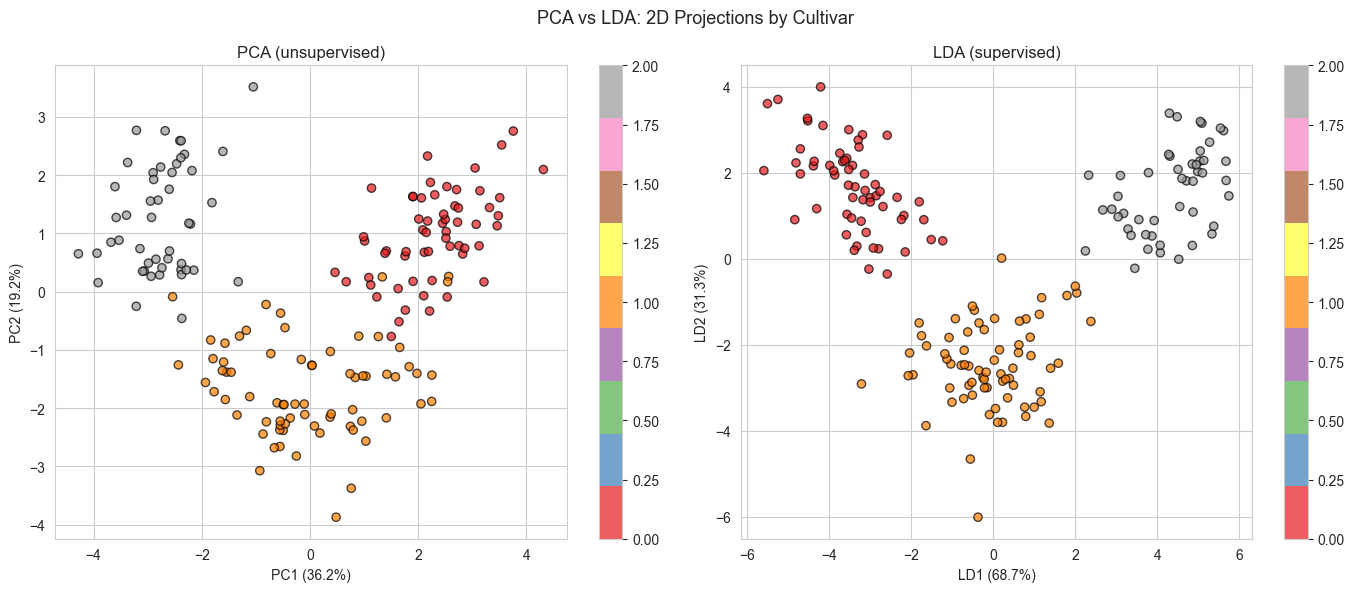


LDA provides better class separation because it maximizes between-class variance.
With only 2 components, LDA captures the discriminative structure better than PCA.


In [85]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# LDA: supervised dimensionality reduction (max n_classes - 1 = 2 components)
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_clust_scaled, df["class"])

print(f"LDA explained variance ratio: {lda.explained_variance_ratio_.round(4)}")
print(f"Total explained: {lda.explained_variance_ratio_.sum()*100:.1f}%")

# Compare PCA vs LDA projections
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

scatter1 = ax1.scatter(X_pca_full[:, 0], X_pca_full[:, 1], c=df["class"],
                       cmap="Set1", edgecolors="k", alpha=0.7)
ax1.set_xlabel(f"PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}%)")
ax1.set_ylabel(f"PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}%)")
ax1.set_title("PCA (unsupervised)")
plt.colorbar(scatter1, ax=ax1)

scatter2 = ax2.scatter(X_lda[:, 0], X_lda[:, 1], c=df["class"],
                       cmap="Set1", edgecolors="k", alpha=0.7)
ax2.set_xlabel(f"LD1 ({lda.explained_variance_ratio_[0]*100:.1f}%)")
ax2.set_ylabel(f"LD2 ({lda.explained_variance_ratio_[1]*100:.1f}%)")
ax2.set_title("LDA (supervised)")
plt.colorbar(scatter2, ax=ax2)

plt.suptitle("PCA vs LDA: 2D Projections by Cultivar", fontsize=13)
plt.tight_layout()
plt.show()

print("\nLDA provides better class separation because it maximizes between-class variance.")
print("With only 2 components, LDA captures the discriminative structure better than PCA.")


### Recursive Feature Elimination (RFE)

RFE recursively removes the least important features, building a model at each step.
It ranks features by importance and finds the optimal subset.

**Benefits:**
- Reduces overfitting by removing noisy features
- Improves model interpretability
- Can speed up training and prediction


In [86]:
# TODO: Apply RFE for feature selection
# RFE recursively removes the least important features.
# RFECV uses cross-validation to find the optimal subset.

# from sklearn.feature_selection import RFE, RFECV
# from sklearn.linear_model import LogisticRegression

# X = df.drop("class", axis=1).select_dtypes(include=[np.number])
# if "Cluster" in X.columns:
#     X = X.drop("Cluster", axis=1)
# X_scaled = StandardScaler().fit_transform(X)
# y = df["class"]
#
# Step 1: Fit RFE
# estimator = LogisticRegression(max_iter=1000, random_state=42)
# rfe = RFE(estimator=estimator, n_features_to_select=min(10, X_scaled.shape[1]), step=1)
# rfe.fit(X_scaled, y)
#
# Step 2: Display feature rankings
# ranking_df = pd.DataFrame({
#     'Feature': X.columns,
#     'Rank': rfe.ranking_,
#     'Selected': rfe.support_,
# }).sort_values('Rank')
# print(ranking_df)
#
# Step 3: RFECV for automatic feature count
# rfecv = RFECV(estimator=estimator, step=1, cv=5, scoring='accuracy')
# rfecv.fit(X_scaled, y)
# print(f"Optimal features: {rfecv.n_features_}")
#
# Step 4: Plot CV accuracy vs feature count
# plt.plot(range(len(rfecv.cv_results_['mean_test_score'])),
#          rfecv.cv_results_['mean_test_score'], 'bo-')
# plt.axvline(x=rfecv.n_features_, color='r', linestyle='--')
# plt.title('RFE: Optimal Feature Count'); plt.show()


Optimal number of features: 8
Best CV F1 Macro: 0.9892

Selected features (8):
  1. alcohol (rank: 1)
  2. ash (rank: 1)
  3. alcalinity_of_ash (rank: 1)
  4. flavanoids (rank: 1)
  5. color_intensity (rank: 1)
  6. hue (rank: 1)
  7. od280_od315 (rank: 1)
  8. proline (rank: 1)

Eliminated features (5):
  - malic_acid (rank: 3)
  - magnesium (rank: 6)
  - total_phenols (rank: 4)
  - nonflavanoid_phenols (rank: 5)
  - proanthocyanins (rank: 2)


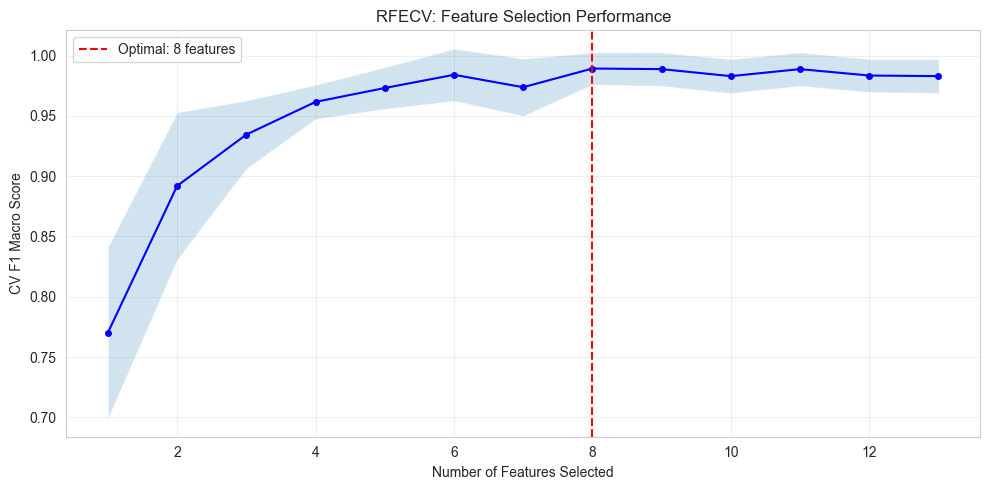

In [91]:
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

# RFECV: Recursive Feature Elimination with Cross-Validation
estimator = LogisticRegression(max_iter=5000, random_state=42, solver="lbfgs")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rfecv = RFECV(estimator=estimator, step=1, cv=cv, scoring="f1_macro", n_jobs=-1)
rfecv.fit(X_clust_scaled, df["class"])

print(f"Optimal number of features: {rfecv.n_features_}")
print(f"Best CV F1 Macro: {rfecv.cv_results_['mean_test_score'].max():.4f}")

# Selected features
selected_mask = rfecv.support_
selected_features = np.array(original_features)[selected_mask].tolist()
eliminated_features = np.array(original_features)[~selected_mask].tolist()
print(f"\nSelected features ({len(selected_features)}):")
for i, f in enumerate(selected_features, 1):
    print(f"  {i}. {f} (rank: {rfecv.ranking_[original_features.index(f)]})")

if eliminated_features:
    print(f"\nEliminated features ({len(eliminated_features)}):")
    for f in eliminated_features:
        print(f"  - {f} (rank: {rfecv.ranking_[original_features.index(f)]})")

# Plot number of features vs CV score
plt.figure(figsize=(10, 5))
n_features_range = range(1, len(original_features) + 1)
plt.plot(n_features_range, rfecv.cv_results_["mean_test_score"], 'b-o', markersize=4)
plt.fill_between(n_features_range,
                 rfecv.cv_results_["mean_test_score"] - rfecv.cv_results_["std_test_score"],
                 rfecv.cv_results_["mean_test_score"] + rfecv.cv_results_["std_test_score"],
                 alpha=0.2)
plt.axvline(x=rfecv.n_features_, color='r', linestyle='--',
            label=f'Optimal: {rfecv.n_features_} features')
plt.xlabel("Number of Features Selected")
plt.ylabel("CV F1 Macro Score")
plt.title("RFECV: Feature Selection Performance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()